# Tutorial 1: The geometric absorption law

This tutorial introduces the core physics equation in AEGIS and walks through the full incoherent dosimetry pipeline: building a mesh, defining tissue, creating propagation paths, computing absorbed power density, and visualizing the result.

## The core equation

Every fidelity level in AEGIS is a refinement of the same base equation. At level 2 (the geometric kernel), absorbed power density at a surface point $\mathbf{r}$ is:

$$S_{\mathrm{ab}}(\mathbf{r}) = S_{\mathrm{inc}} \cdot T_0 \cdot [\hat{n}(\mathbf{r}) \cdot (-\hat{k})]_+$$

The notation $[\cdot]_+$ denotes ReLU (the positive-part function), which enforces that only illuminated surface patches absorb power. $\hat{n}(\mathbf{r})$ is the outward surface normal, $\hat{k}$ is the unit direction of wave propagation, and $-\hat{k}$ points back toward the source. The dot product $\hat{n} \cdot (-\hat{k})$ is the cosine of the incidence angle, often written $\cos\theta_i$.

$T_0$ is the normal-incidence power transmission coefficient, derived from the tissue's complex refractive index via the Fresnel formula:

$$T_0 = \frac{4 \operatorname{Re}(\tilde{n})}{(1 + \operatorname{Re}(\tilde{n}))^2 + \operatorname{Im}(\tilde{n})^2}$$

where $\tilde{n} = n' - jn''$ is the complex refractive index. At 28 GHz in skin, $T_0 \approx 0.52$. This constant enters at level 2; higher levels replace it with the full angle-dependent Fresnel coefficient.

## Setup

Install AEGIS with visualization support (`pip install -e ".[viz]"`), then import:

In [1]:
import numpy as np
import aegis
from aegis import DosimetryEngine
from aegis.geometry.mesh import BodyMesh
from aegis.paths import PropagationPaths
from aegis.tissue.dielectric import TissueModel

## Create a body mesh

AEGIS represents the human body (or any phantom) as a triangulated surface mesh. For this tutorial, a sphere stands in for a torso cross-section:

In [2]:
body = BodyMesh.sphere(radius=0.1, n_subdivisions=3)
print(f"Mesh: {body.n_triangles} triangles, total area = {body.total_area:.4f} m^2")

Mesh: 1280 triangles, total area = 0.1251 m^2


`n_subdivisions=3` starts from a 20-triangle icosahedron and subdivides four times (each pass multiplies the count by 4), yielding 1280 triangles. A finer mesh (more subdivisions) reduces discretization error but increases computation time. For a sphere of radius $r = 0.1$ m, the theoretical surface area is $4\pi r^2 \approx 0.1257$ m$^2$.

The key mesh attributes are:
- `body.normals` -- (M, 3) outward unit normals per triangle
- `body.centroids` -- (M, 3) triangle centroids
- `body.areas` -- (M,) triangle areas in m$^2$
- `body.total_area` -- scalar sum of all areas

## Define tissue

`TissueModel` holds the electromagnetic properties of the surface tissue at a specific frequency:

In [4]:
tissue = TissueModel.from_params("Skin", eps_r=17.0, sigma=25.0, freq_hz=28e9)
print(f"T0 = {tissue.T0:.4f}")         # normal-incidence transmission coefficient
print(f"n_tilde = {tissue.n_complex:.3f}")  # complex refractive index

T0 = 0.5387
n_tilde = 4.493-1.786j


`eps_r` is the relative permittivity and `sigma` is the conductivity in S/m. These values for skin at 28 GHz are taken from the IT'IS v5.0 database. You can look them up directly with:

In [5]:
tissue = TissueModel.from_database("Skin", freq_hz=28e9)

The engine wraps tissue inside `DosimetryEngine`:

In [6]:
engine = DosimetryEngine(tissue)

## Create a plane wave

`PropagationPaths` is the interface between a ray tracer (or an analytic source model) and the dosimetry engine. For a single plane wave, use `from_powers`:

In [7]:
# Wave propagating in the -z direction (downward), hitting the sphere from above
k_hat = np.array([[0.0, 0.0, -1.0]])   # (1, 3) unit direction of propagation
power = np.array([10.0])               # incident power density [W/m^2]

paths = PropagationPaths.from_powers(k_hat=k_hat, power=power)
print(paths)  # PropagationPaths(n_paths=1, n_elements=1)

PropagationPaths(n_paths=1, n_elements=1)


`k_hat` points in the direction the wave travels, not toward the source. A wave arriving from above travels in the $-z$ direction, so `k_hat = [0, 0, -1]`. The ReLU factor $[\hat{n} \cdot (-\hat{k})]_+$ becomes $[\hat{n} \cdot \hat{z}]_+$, which is nonzero only on the upper hemisphere. This is the mathematical statement that you cannot absorb power through the far side of the body.

`from_powers` accepts any shape that broadcasts to (N, 3) for `k_hat` and (N,) for `power`. It normalizes directions automatically.

## Compute dosimetry

In [8]:
result = engine.compute(body, paths, level=2)

print(f"Peak S_ab:       {result.peak_sab:.4f} W/m^2")
print(f"Mean S_ab:       {result.mean_sab:.4f} W/m^2")
print(f"Total P_abs:     {result.p_abs:.6f} W")
print(f"Fidelity level:  {result.fidelity_level}")

Peak S_ab:       5.3401 W/m^2
Mean S_ab:       1.3392 W/m^2
Total P_abs:     0.167519 W
Fidelity level:  2


`level=2` selects the geometric kernel, which applies $T_0$ and the ReLU projection per triangle. The result is a `DosimetryResult` with per-triangle $S_{\mathrm{ab}}$ values in `result.sab`.

## Visualize

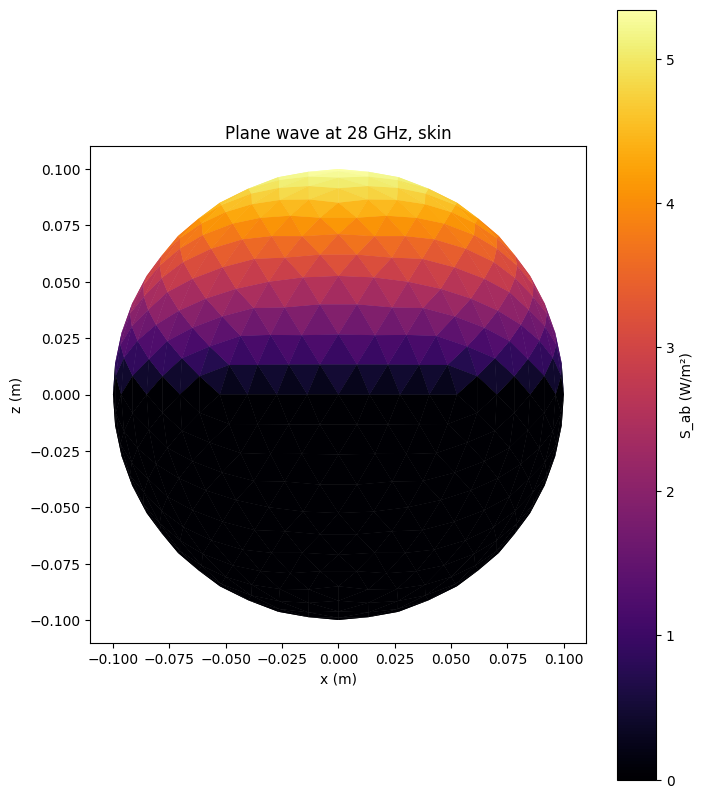

In [9]:
result.show(
    body,
    backend="matplotlib",
    show=False,
    title="Plane wave at 28 GHz, skin",
)
import matplotlib.pyplot as plt
plt.savefig("sab_sphere.png", dpi=150, bbox_inches="tight")

The heatmap renders each triangle colored by $S_{\mathrm{ab}}$. You should see a bright cap at the top (illuminated hemisphere) and zero on the bottom half. The peak occurs at the triangle whose normal is most closely aligned with $-\hat{k}$, which for a downward-propagating wave is the triangle nearest the north pole.

Pass `averaged=True` to visualize the spatially averaged $S_{\mathrm{ab}}$ instead:

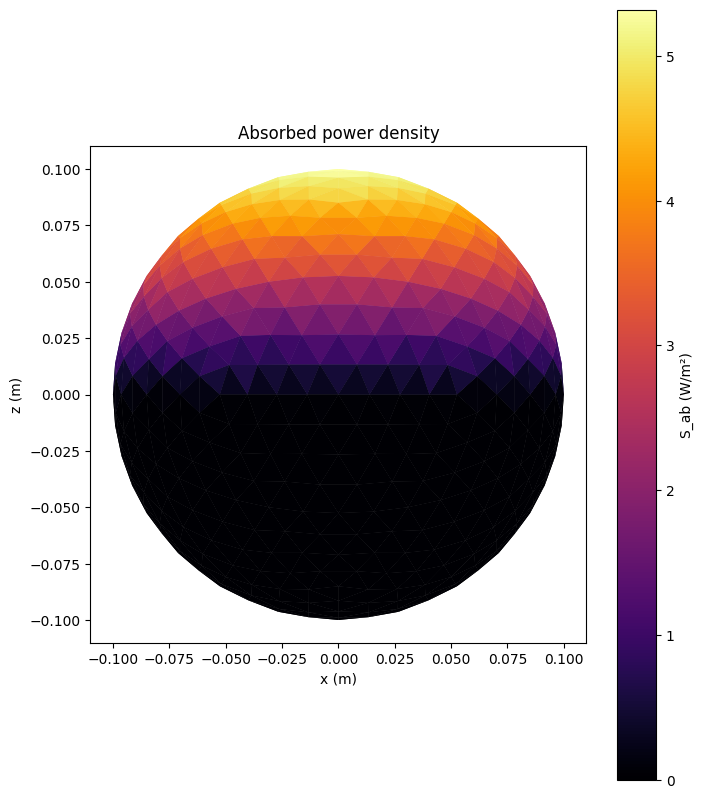

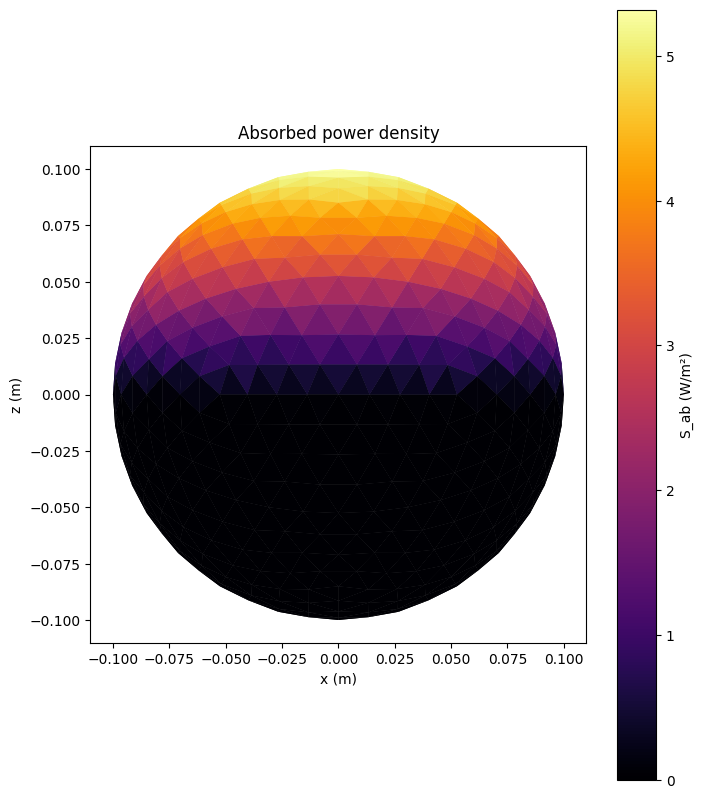

In [10]:
result.show(body, averaged=True, backend="matplotlib", show=False)

The spatial average smooths sharp triangle-by-triangle variation and corresponds to the ICNIRP 4 cm$^2$ averaging area used in compliance assessment.

## Total absorbed power and projected area

The total absorbed power $P_{\mathrm{abs}}$ is the surface integral of $S_{\mathrm{ab}}$:

$$P_{\mathrm{abs}} = \int_{\partial V} S_{\mathrm{ab}}(\mathbf{r}) \, dA = S_{\mathrm{inc}} \cdot T_0 \cdot \int_{\partial V} [\hat{n}(\mathbf{r}) \cdot (-\hat{k})]_+ \, dA$$

For a convex body and a single incident direction, the integral of $[\hat{n} \cdot (-\hat{k})]_+$ over the surface equals the projected area $A_\perp$ -- the shadow area of the body on a plane perpendicular to $\hat{k}$. This follows from the divergence theorem. The result is simply:

$$P_{\mathrm{abs}} = S_{\mathrm{inc}} \cdot T_0 \cdot A_\perp$$

For a sphere of radius $r$, $A_\perp = \pi r^2$ regardless of illumination direction. We can verify this numerically:

In [11]:
S_inc = 10.0        # W/m^2
T0 = tissue.T0
r = 0.1             # sphere radius [m]
A_perp = np.pi * r**2

P_expected = S_inc * T0 * A_perp
P_computed = result.p_abs

print(f"Expected P_abs:  {P_expected:.6f} W")
print(f"Computed P_abs:  {P_computed:.6f} W")
print(f"Relative error:  {abs(P_computed - P_expected) / P_expected * 100:.3f}%")

Expected P_abs:  0.168373 W
Computed P_abs:  0.167519 W
Relative error:  0.507%


The relative error should be below 1% for 1280 triangles and will decrease with finer meshes. The residual error is a discretization artifact: the icosphere approximates a sphere, so the discrete projected area is slightly off.

## Multipath illumination

Real wireless environments have many arriving paths, not just one. For a uniform diffuse field (energy arriving equally from all directions), use `uniform_sphere`:

In [12]:
paths_multi = PropagationPaths.uniform_sphere(n_paths=200, total_power=1.0, seed=42)
result_multi = engine.compute(body, paths_multi, level=2)
print(f"Multipath P_abs: {result_multi.p_abs:.6f} W")

Multipath P_abs: 0.016757 W


Because dosimetry at levels 0-6 is incoherent, the total $S_{\mathrm{ab}}$ is a linear superposition of contributions from each path:

$$S_{\mathrm{ab}}(\mathbf{r}) = T_0 \sum_{n=1}^{N} S_n \cdot [\hat{n}(\mathbf{r}) \cdot (-\hat{k}_n)]_+$$

where $S_n$ and $\hat{k}_n$ are the power density and direction of the $n$-th path.

For isotropic illumination at total power density $S_{\mathrm{inc}}$ (integrated over all directions), the expected absorbed power satisfies the Cauchy mean projection formula. The mean projected area of a convex surface equals one quarter of its total area $A_{\mathrm{ab}}$:

$$\langle P_{\mathrm{abs}} \rangle = S_{\mathrm{inc}} \cdot T_0 \cdot \frac{A_{\mathrm{ab}}}{4}$$

For a sphere, $A_{\mathrm{ab}} = 4\pi r^2$, so $A_{\mathrm{ab}}/4 = \pi r^2$, matching the single-direction result. You can verify:

In [13]:
A_ab = body.total_area          # total surface area
P_cauchy = 1.0 * T0 * A_ab / 4
print(f"Cauchy prediction: {P_cauchy:.6f} W")
print(f"Computed:          {result_multi.p_abs:.6f} W")

Cauchy prediction: 0.016757 W
Computed:          0.016757 W


The agreement improves with more paths. At 200 paths, the Monte Carlo sampling error is roughly $1/\sqrt{200} \approx 7\%$.

## Spherical coordinates

If your paths are specified by azimuth and elevation rather than Cartesian vectors, use `from_spherical`:

In [14]:
# Single path: theta=90 deg (broadside), phi=0 deg (x-axis)
theta = np.array([np.pi / 2])
phi = np.array([0.0])
power_single = np.array([10.0])

paths_sph = PropagationPaths.from_spherical(theta, phi, power_single)
result_sph = engine.compute(body, paths_sph, level=2)
print(f"Spherical path P_abs: {result_sph.p_abs:.6f} W")

Spherical path P_abs: 0.167519 W


The convention is physics spherical coordinates: $\theta$ is the zenith angle (0 points along $+z$, $\pi/2$ is equatorial), and $\phi$ is the azimuth. Internally, `from_spherical` converts to Cartesian and calls `from_powers`.

## Inspecting the result

`DosimetryResult` exposes several useful fields and properties:

In [15]:
print(result.sab.shape)             # (M,) per-triangle absorbed power density
print(result.sab_averaged.shape)    # (M,) spatially averaged over 4 cm^2 (ICNIRP)
print(result.sinc.shape)            # (M,) per-triangle incident power density
print(result.peak_sab)              # float: max(sab)
print(result.peak_sab_averaged)     # float: max(sab_averaged), used for compliance
print(result.mean_sab)              # float: mean(sab)
print(result.p_abs)                 # float: total absorbed power [W]
print(result.fidelity_level)        # int: which kernel produced this result

(1280,)
(1280,)
(1280,)
5.340104802677027
5.321546692282121
1.3392308368876362
0.16751895242472556
2


To save and reload a result:

In [16]:
d = result.to_dict()
result2 = aegis.DosimetryResult.from_dict(d)

`to_dict` returns a JSON-friendly dict. Complex arrays (used in coherent results) are serialized as `{"real": [...], "imag": [...]}`. `to_json` and `from_json` wrap this with `json.dumps`/`json.loads`.

You can also scale a result by a power factor without recomputing, since $S_{\mathrm{ab}}$ is linear in transmitted power at all incoherent levels:

In [17]:
result_100W = result.scale(10.0)    # 10x more transmit power
print(f"Scaled P_abs: {result_100W.p_abs:.4f} W")

Scaled P_abs: 1.6752 W


## Next steps

- [Tutorial 2: Fidelity levels and convergence](fidelity_levels.md) -- the nine-level hierarchy, `sweep_levels`, comparison plots
- [Tutorial 3: Tissue physics and Fresnel transmission](tissue_and_fresnel.md) -- Cole-Cole model, Fresnel transmission, level 3 vs level 2
- [Tutorial 4: ICNIRP 2020 compliance](compliance.md) -- regulatory limits, compliance evaluation, power sweeps
- [Tutorial 5: Coherent MIMO and ECBF](coherent_mimo.md) -- field channel, exposure operator, exposure-constrained beamforming